In [11]:
!rm -rf "/content/UCI HAR Dataset"
!rm -f "/content/har.zip"

In [12]:
!wget -q "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip" -O /content/har.zip

In [13]:
import zipfile

with zipfile.ZipFile("/content/har.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed!")

Extraction completed!


In [15]:
import zipfile

zip_path = "/content/har.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Number of files:", len(files))
print("\nFirst 30 files:")
for f in files[:30]:
    print(f)

print("\nLooking for X_train:")
for f in files:
    if "X_train" in f:
        print("FOUND:", f)

Number of files: 2

First 30 files:
UCI HAR Dataset.names
UCI HAR Dataset.zip

Looking for X_train:


In [16]:
import zipfile
import os

# Extract the INNER dataset ZIP
inner_zip = "/content/UCI HAR Dataset.zip"

with zipfile.ZipFile(inner_zip, "r") as z:
    z.extractall("/content")

print("Dataset extracted!")

# Check the train folder
print(os.listdir("/content/UCI HAR Dataset/train"))

Dataset extracted!
['y_train.txt', 'Inertial Signals', 'subject_train.txt', 'X_train.txt']


In [17]:
import pandas as pd

X_train = pd.read_csv(
    "/content/UCI HAR Dataset/train/X_train.txt",
    sep=r"\s+",
    header=None
)

print(X_train.shape)
print(X_train.head())

(7352, 561)
        0         1         2         3         4         5         6    \
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3  0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4  0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   

        7         8         9    ...       551       552       553       554  \
0 -0.983185 -0.923527 -0.934724  ... -0.074323 -0.298676 -0.710304 -0.112754   
1 -0.974914 -0.957686 -0.943068  ...  0.158075 -0.595051 -0.861499  0.053477   
2 -0.963668 -0.977469 -0.938692  ...  0.414503 -0.390748 -0.760104 -0.118559   
3 -0.982750 -0.989302 -0.938692  ...  0.404573 -0.117290 -0.482845 -0.036788   
4 -0.979672 -0.990441 -0.942469  ...  0.087753 -0.351471 -0.699205  0.123320   

        555       556       557       558       559     

In [18]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score,
                             normalized_mutual_info_score)
from scipy.cluster.hierarchy import linkage, dendrogram

In [19]:
D = "/content/UCI HAR Dataset/"
X = pd.read_csv(D + "train/X_train.txt", sep=r"\s+", header=None)
y = pd.read_csv(D + "train/y_train.txt", header=None)[0]
acts = pd.read_csv(D + "activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]

X = X.fillna(X.median())                    # missing values
le = LabelEncoder()
y = le.fit_transform(y.map(acts))           # encode labels
names = le.classes_
Xs = StandardScaler().fit_transform(X)      # standardization
print(X.shape, dict(zip(range(6), names)))

(7352, 561) {0: 'LAYING', 1: 'SITTING', 2: 'STANDING', 3: 'WALKING', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_UPSTAIRS'}


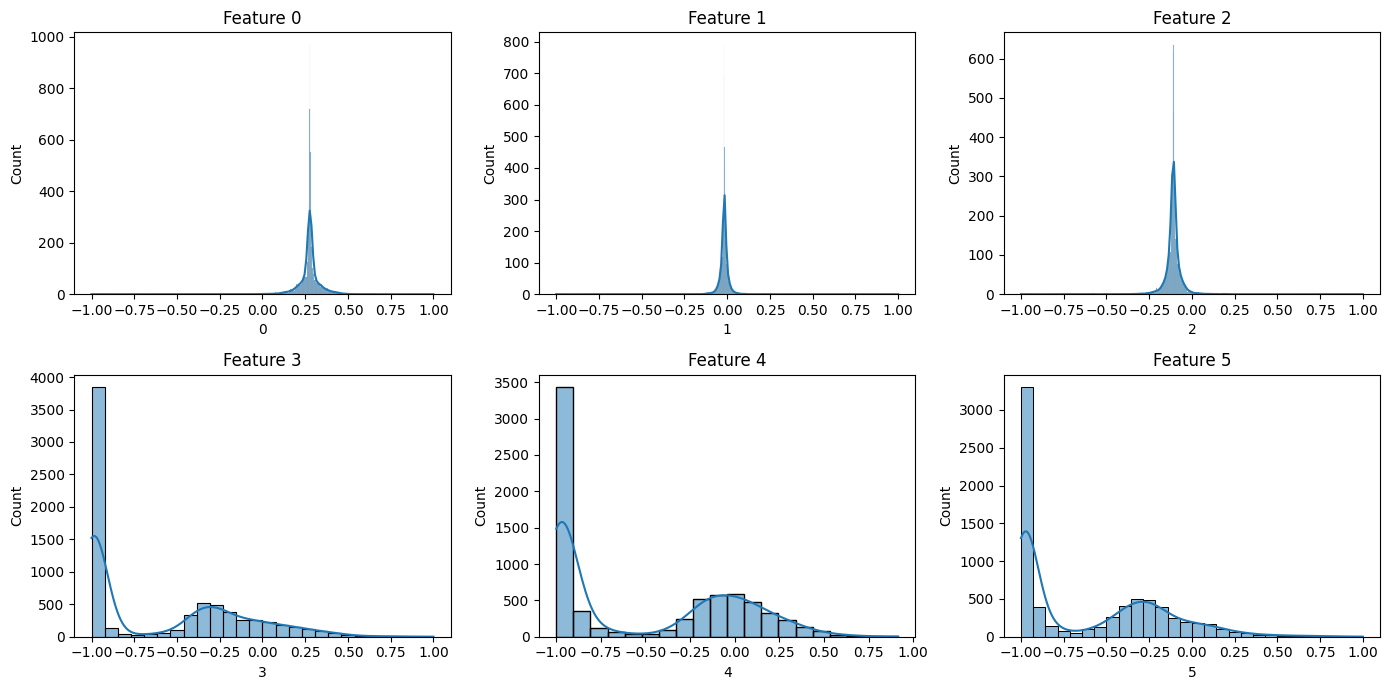

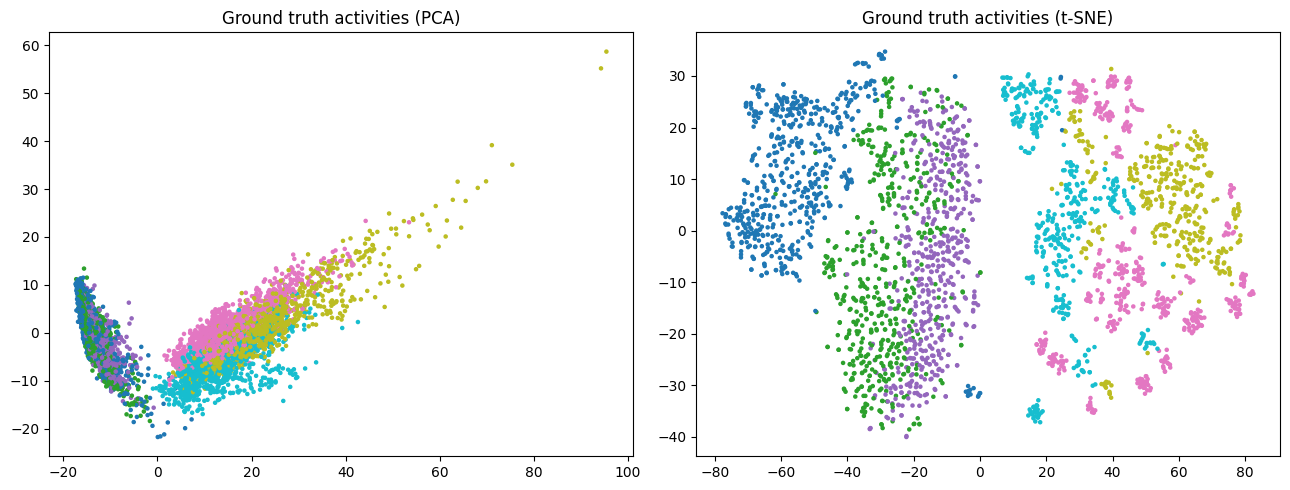

In [20]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for a, c in zip(ax.ravel(), X.columns[:6]):
    sns.histplot(X[c], kde=True, ax=a); a.set_title(f"Feature {c}")
plt.tight_layout(); plt.show()

X2 = PCA(2).fit_transform(Xs)               # for plots
X50 = PCA(50).fit_transform(Xs)             # for DBSCAN
idx = np.random.RandomState(0).choice(len(Xs), 3000, replace=False)
T = TSNE(2, init="pca", random_state=0).fit_transform(Xs[idx])   # t-SNE on subsample

def show(lab, title):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for a, E, l, n in [(ax[0], X2, lab, "PCA"), (ax[1], T, lab[idx], "t-SNE")]:
        a.scatter(E[:, 0], E[:, 1], c=l, s=5, cmap="tab10"); a.set_title(f"{title} ({n})")
    plt.tight_layout(); plt.show()

show(y, "Ground truth activities")

   k         WCSS  Silhouette
0  2  2336223.752       0.397
1  3  2081849.627       0.327
2  4  1976450.561       0.163
3  5  1875065.694       0.132
4  6  1818833.958       0.110
5  7  1776046.018       0.104
6  8  1735669.986       0.083


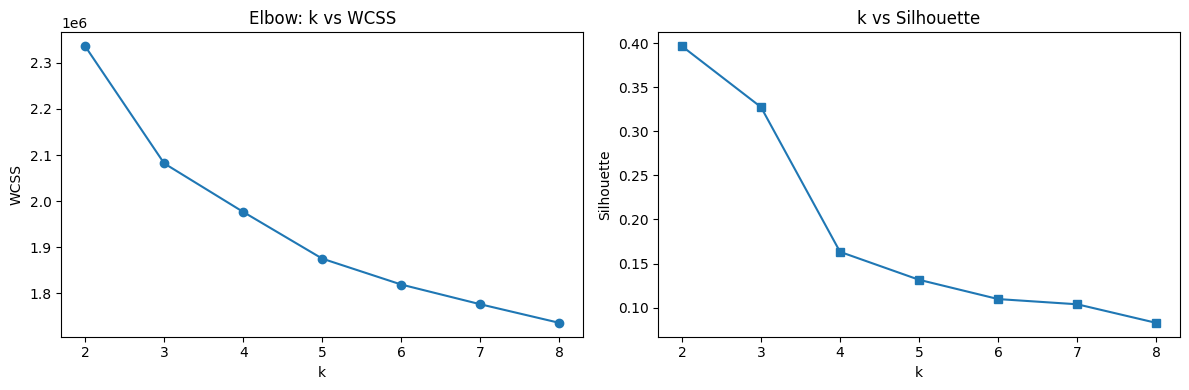

Best k: 2


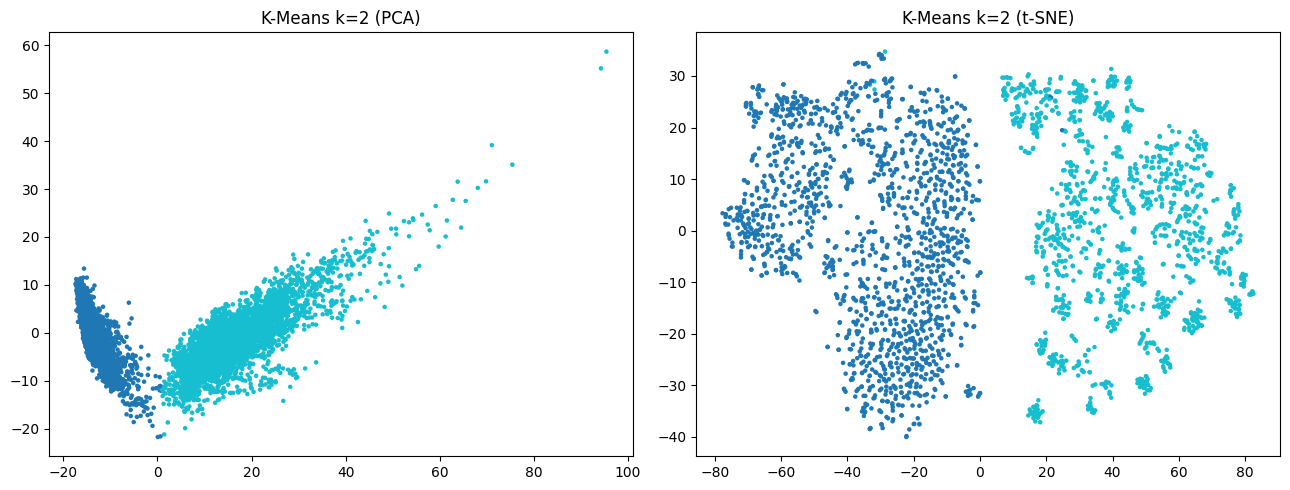

In [21]:
ks = list(range(2, 9))
kms = [KMeans(k, n_init=10, random_state=0).fit(Xs) for k in ks]
wcss = [m.inertia_ for m in kms]
sil = [silhouette_score(Xs, m.labels_) for m in kms]
print(pd.DataFrame({"k": ks, "WCSS": wcss, "Silhouette": sil}).round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, wcss, "o-"); ax[0].set(title="Elbow: k vs WCSS", xlabel="k", ylabel="WCSS")
ax[1].plot(ks, sil, "s-");  ax[1].set(title="k vs Silhouette", xlabel="k", ylabel="Silhouette")
plt.tight_layout(); plt.show()

best_k = ks[int(np.argmax(sil))]
km = kms[ks.index(best_k)]
print("Best k:", best_k)
show(km.labels_, f"K-Means k={best_k}")

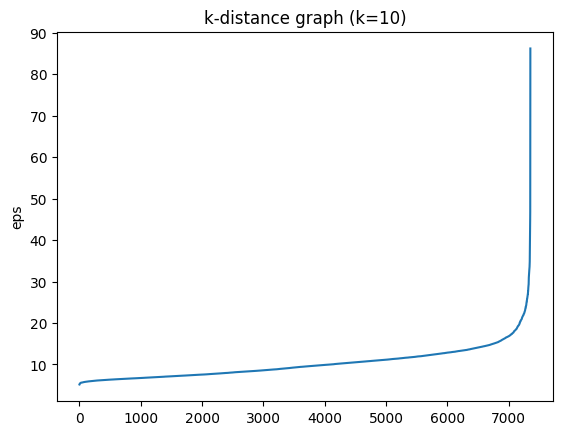

       eps  minPts  clusters  noise    sil
0   11.346       5        18   1154  0.349
1   11.346      10         9   1411  0.385
2   11.346      20         3   1762  0.373
3   12.581       5         7    653  0.051
4   12.581      10         6    830  0.225
5   12.581      20         4   1140  0.306
6   14.448       5         2    298  0.381
7   14.448      10         2    385  0.339
8   14.448      20         2    498  0.339
9   16.695       5         1    171    NaN
10  16.695      10         1    191    NaN
11  16.695      20         1    230    NaN
Chosen eps=11.35, minPts=10, noise points=1411


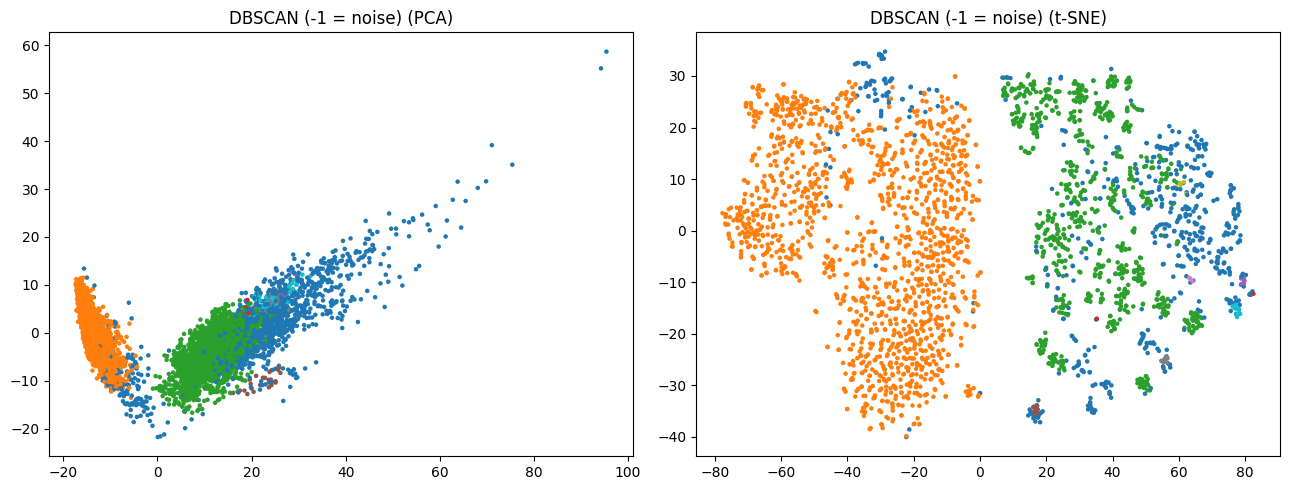

In [22]:
kd = np.sort(NearestNeighbors(n_neighbors=10).fit(X50).kneighbors(X50)[0][:, -1])
plt.plot(kd); plt.title("k-distance graph (k=10)"); plt.ylabel("eps"); plt.show()

rows = []
for eps in np.percentile(kd, [70, 80, 90, 95]):
    for mp in [5, 10, 20]:
        l = DBSCAN(eps=eps, min_samples=mp).fit_predict(X50)
        m = l != -1; n = len(set(l[m]))
        rows.append({"eps": eps, "minPts": mp, "clusters": n, "noise": int((~m).sum()),
                     "sil": silhouette_score(X50[m], l[m]) if n > 1 else np.nan})
g = pd.DataFrame(rows); print(g.round(3))

ok = g[(g.clusters > 1) & (g.noise < 0.5 * len(X50))].dropna()
b = ok.loc[ok.sil.idxmax()] if len(ok) else g.iloc[-1]
db = DBSCAN(eps=b.eps, min_samples=int(b.minPts)).fit_predict(X50)
print(f"Chosen eps={b.eps:.2f}, minPts={int(b.minPts)}, noise points={(db == -1).sum()}")
show(db, "DBSCAN (-1 = noise)")

          Model  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI    NMI
0      HAC-ward       0.083           2.786           1730.836  0.279  0.454
1  HAC-complete       0.304           1.401            506.998  0.048  0.148
2   HAC-average       0.516           0.655             32.593  0.000  0.003
3    HAC-single       0.545           0.281             26.111  0.000  0.002


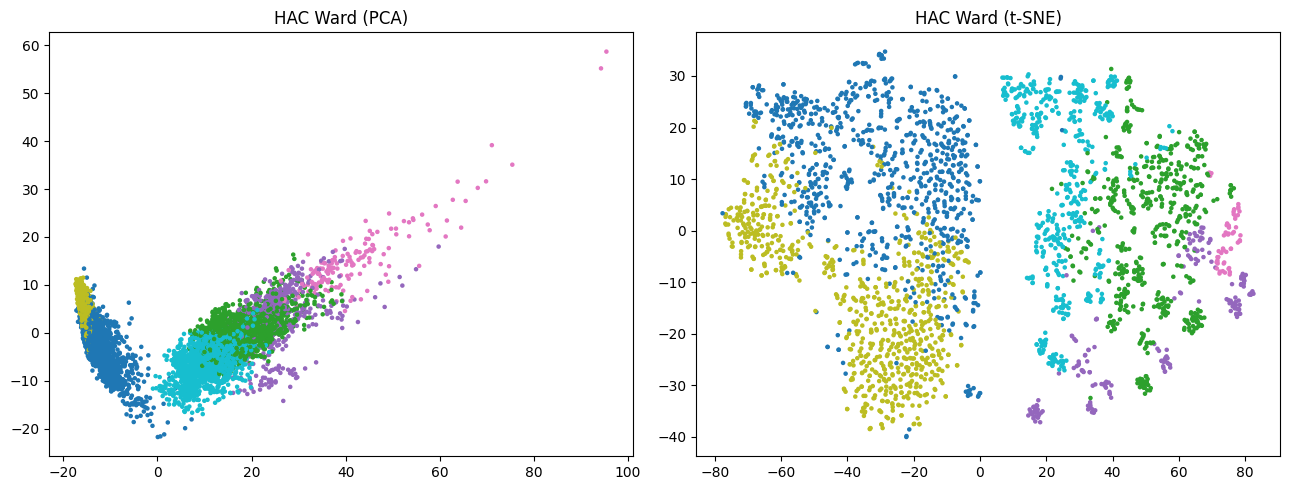

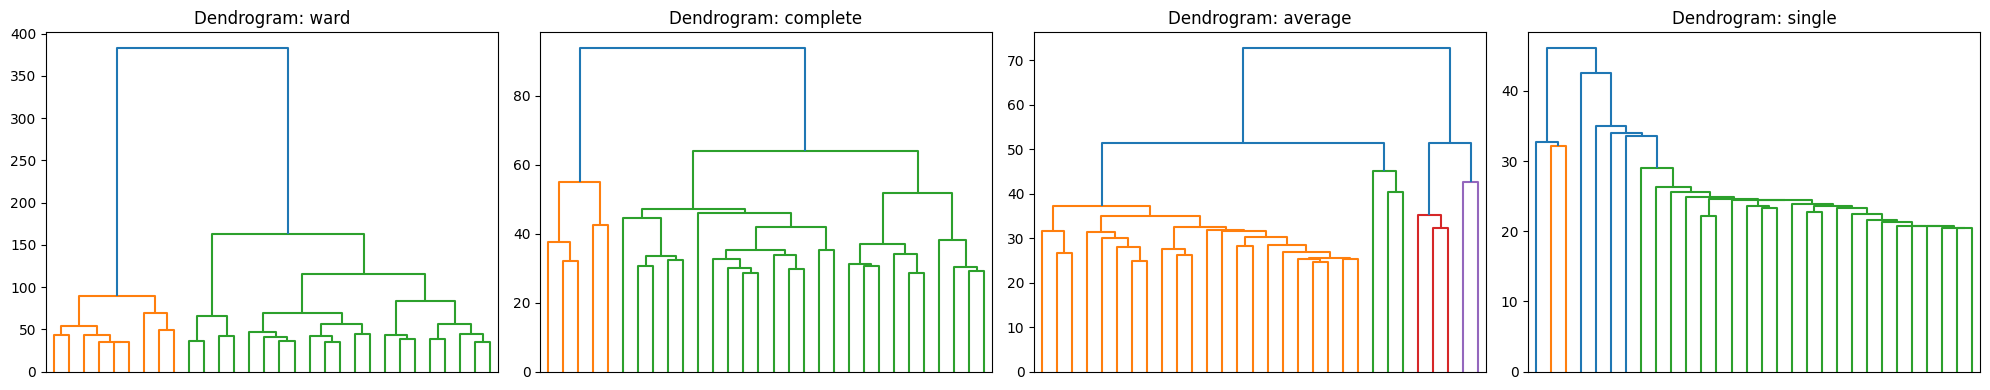

In [23]:
def metrics(name, Z, l):
    m = l != -1; ok = len(set(l[m])) > 1
    return {"Model": name,
            "Silhouette": silhouette_score(Z[m], l[m]) if ok else np.nan,
            "Davies-Bouldin": davies_bouldin_score(Z[m], l[m]) if ok else np.nan,
            "Calinski-Harabasz": calinski_harabasz_score(Z[m], l[m]) if ok else np.nan,
            "ARI": adjusted_rand_score(y, l), "NMI": normalized_mutual_info_score(y, l)}

lk = {L: AgglomerativeClustering(n_clusters=6, linkage=L).fit_predict(Xs)
      for L in ["ward", "complete", "average", "single"]}
print(pd.DataFrame([metrics(f"HAC-{L}", Xs, l) for L, l in lk.items()]).round(3))

hac = lk["ward"]
show(hac, "HAC Ward")

sub = Xs[idx[:300]]
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for a, L in zip(ax, lk):
    dendrogram(linkage(sub, L), truncate_mode="lastp", p=30, ax=a, no_labels=True)
    a.set_title(f"Dendrogram: {L}")
plt.tight_layout(); plt.show()

            Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI    NMI
Model                                                                  
KMeans k=2       0.397           1.069           5626.013  0.328  0.543
DBSCAN           0.385           1.115            962.946  0.324  0.479
HAC Ward         0.083           2.786           1730.836  0.279  0.454


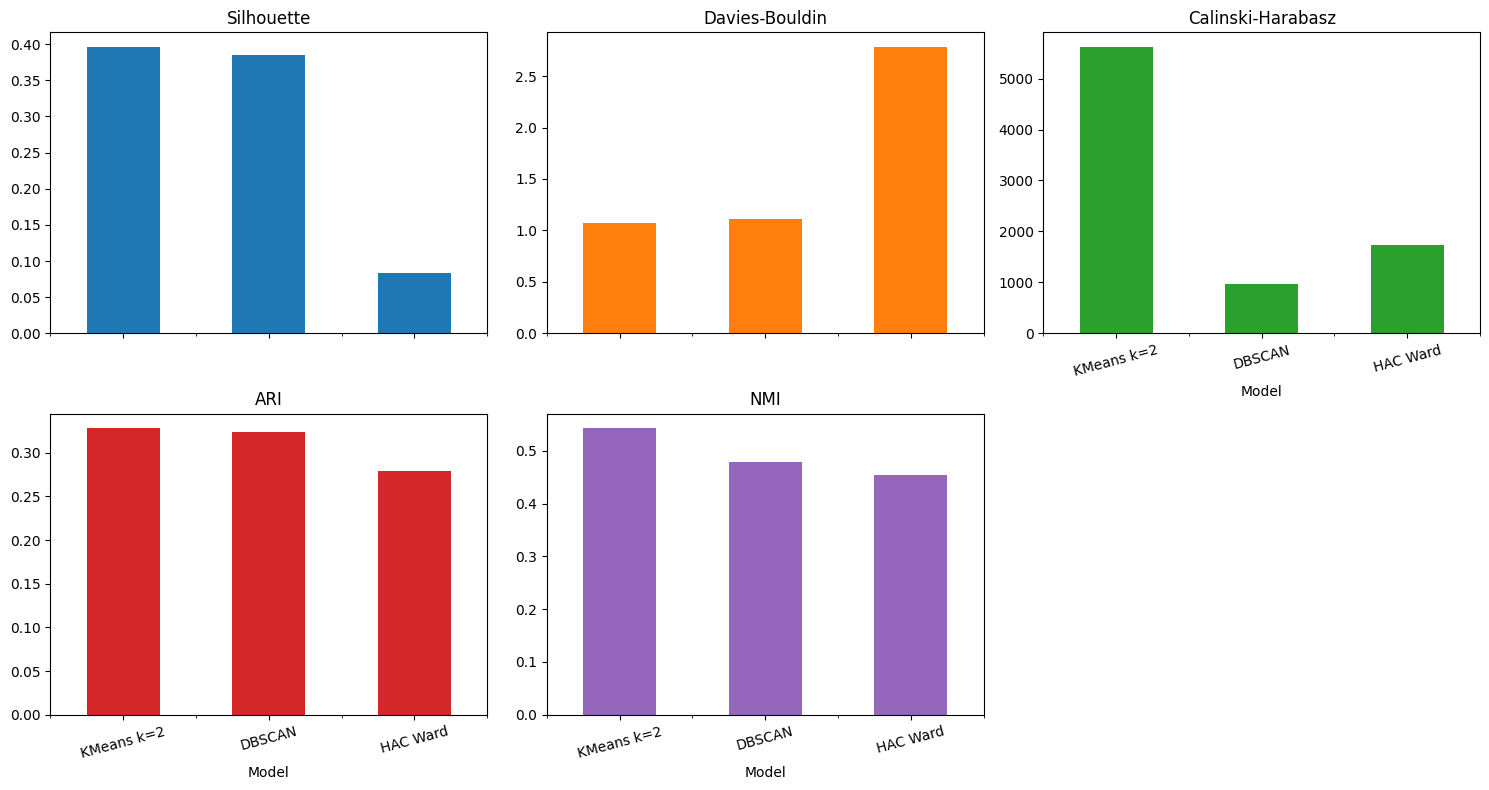

In [24]:
res = pd.DataFrame([metrics(f"KMeans k={best_k}", Xs, km.labels_),
                    metrics("DBSCAN", X50, db),
                    metrics("HAC Ward", Xs, hac)]).set_index("Model")
print(res.round(3))

res.plot.bar(subplots=True, layout=(2, 3), figsize=(15, 8), legend=False, rot=15)
plt.tight_layout(); plt.show()